**Implementing the 7-node example from study brief**

We have a 7-node pipeline graph  given by `edges` (0th indexed - node 1 = 0), noisy data `y` (with an anomaly at node 4), and the actual data at each node `x_true`.

In [179]:
import numpy as np
from scipy import sparse
from pygsp import graphs
import matplotlib.pyplot as plt


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Graph(n_vertices=7, n_edges=7)'}>)

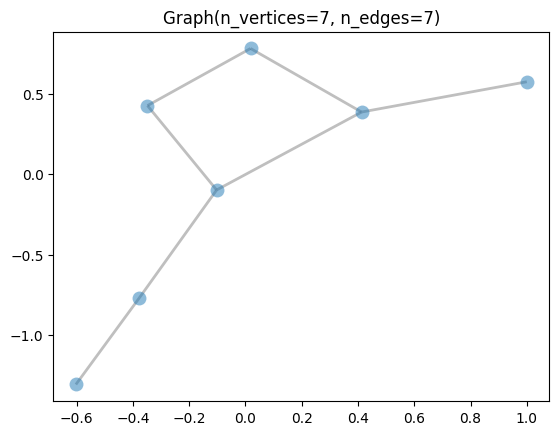

In [180]:
# 7-node pipeline network graph example
def build_graph(edges, laplacian_type="combinatorial"):
    rows, cols, weights = zip(*edges)
    N = max(max(rows), max(cols)) + 1
    W = sparse.coo_matrix((weights, (rows, cols)), shape=((N,N)))
    W = W + W.T
    G = graphs.Graph(W)
    G.compute_laplacian(laplacian_type)
    G.compute_fourier_basis()
    return G

# edge table from worked example with weights edge = (node1, node2, weight)
edges = [
    (0, 1, 1.5),
    (1, 2, 2),
    (2, 3, 1.8),
    (3, 4, 1.2),
    (1, 4, 0.8),
    (4, 5, 2.1),
    (5, 6, 1.6)
]

x_true = np.array([120, 115, 108, 100, 110, 95, 85])
y = np.array([120.15, 114.48, 108.38, 108.47, 109.02, 94.35, 85.06])

G = build_graph(edges)
G.set_coordinates()
G.plot()


**Estimator 1: Dterministic Laplacian-Regularised LS**

$A = I + \gamma L$ and $\hat{x}_{det} = A^{-1} y$

In [181]:
def laplace_reg_ls(gamma=0.3):
       A = np.identity(N) + gamma*G.L.toarray()
       inv_A = np.linalg.inv(A)
       x_det = inv_A @ np.transpose(y)
       return x_det
x_det = laplace_reg_ls()


**Estimator 2: Bayesian GMRF with Inflated Variance**

We have prior precision $Q = 0.3L + 10^{-4}I$ with measurement noise: $\sigma_{i} = 0.5$ bar for all $i\neq4; \sigma_{4} = 15$ bar. The posterior precision matrix is given by, $\Lambda_{post} = Q + R^{-1}$.  

In [186]:
def bayesian_gmrf(G, y):
       Q = 0.3 * G.L.toarray() + 1e-4*np.identity(G.N)
       sigma = np.array([0.25, 0.25, 0.25, 225, 0.25, 0.25, 0.25])
       inv_r = np.diag(1/sigma)
       lambda_post = Q + inv_r
       inv_lambda_post = np.linalg.inv(lambda_post)
       h = inv_r @ y
       x_bay = inv_lambda_post @ h
       post_var = np.diag(inv_lambda_post)
       return (x_bay, post_var, lambda_post, h)
(x_bay, post_var, lambda_post, h) = bayesian_gmrf(G, y)
print(x_bay, post_var)


[119.52282189 113.97446597 109.03572369 108.42563659 107.54007649
  95.20357622  86.14488886] [0.22669742 0.19396252 0.21108934 1.21739878 0.20060133 0.20079162
 0.22551421]


**Spectral Anomaly Check**

$\lVert U_{high}^{\top}y\rVert^{2}$ vs. $\lVert U_{high}^{\top}x_{true}\rVert^{2}$ with $U = ( \lambda_{4}, \lambda_{5}, \lambda_{6} )$ the top-3 graph frequency modes

In [183]:
def spec_anomaly(G, y, k=3):
    U_high = (G.U)[:, -k:]
    Uy = np.linalg.norm(U_high.T @ y)**2
    Ux = np.linalg.norm(U_high.T @ x_true)**2
    return (Uy, Ux, Uy/Ux)
spec_anomaly(G, y, 3)


(np.float64(21.221560552580176),
 np.float64(65.21573565058677),
 np.float64(0.32540552277568674))

**Convergence: Walk-Summability**

GaBP converges iff the matrix $\tilde{\Lambda} = D^{-1/2}\Lambda D^{-1/2}$ (where D = diag($\Lambda$)) satisfies the walk-summability condition: $\rho(\mid \tilde{\Lambda} - I\mid) < 1$.

In [184]:
def walk_convergence(lambda_post):
    # Checking if matrix is diagonally dominant which is equivalent to above statement 
    diag = np.diag(np.abs(lambda_post))
    non_diag = np.sum(np.abs(lambda_post), axis=1) - diag
    if np.all(diag >= non_diag):
        convergence = True
    else:
        convergence = False
    return convergence
walk_convergence(lambda_post)


True

**Gaussian Belief Propagation Alogrithm**

The posterior is a GMRF in information (canonical) form,

$$
p(\mathbf{x}) \;\propto\; \exp\!\Big(-\tfrac12\,\mathbf{x}^\top \Lambda\,\mathbf{x} + \mathbf{h}^\top \mathbf{x}\Big),
\qquad \Lambda = \Lambda_{\text{post}},\quad \mathbf{h} = R^{-1}\mathbf{y},
$$

which factorises over the graph into node potentials
$\phi_i(x_i)=\exp(-\tfrac12\Lambda_{ii}x_i^2 + h_i x_i)$
and edge potentials $\psi_{ij}(x_i,x_j)=\exp(-\Lambda_{ij}x_i x_j)$.
Let $\partial i$ denote the neighbours of node $i$.

**Cavity (sum over all neighbours except the target $j$):**

$$
\hat P_{i\setminus j} = \Lambda_{ii} + \!\!\sum_{k\in\partial i\setminus j}\!\! P_{k\to i},
\qquad
\hat h_{i\setminus j} = h_i + \!\!\sum_{k\in\partial i\setminus j}\!\! m_{k\to i}.
$$

**Messages $i \to j$:**

$$
P_{i\to j} = -\frac{\Lambda_{ij}^{2}}{\hat P_{i\setminus j}},
\qquad
m_{i\to j} = -\frac{\Lambda_{ij}\,\hat h_{i\setminus j}}{\hat P_{i\setminus j}}.
$$

These follow from multiplying $\phi_i$ by the incoming messages and integrating out $x_i$ against $\psi_{ij}$ — a one-dimensional Gaussian integral. Because the joint is Gaussian, every message stays an (unnormalised) Gaussian, so it is fully described by the scalar precision $P_{i\to j}$ and potential $m_{i\to j}$ propagated along each edge.

**Beliefs (marginals):**

$$
P_i = \Lambda_{ii} + \sum_{k\in\partial i} P_{k\to i},
\qquad
\mu_i = \frac{h_i + \sum_{k\in\partial i} m_{k\to i}}{P_i},
\qquad
x_i \sim \mathcal{N}\!\big(\mu_i,\; P_i^{-1}\big).
$$

On a tree these recover the exact marginals. This network contains one cycle ($1\!-\!2\!-\!3\!-\!4\!-\!1$), so this is *loopy* GaBP: if it converges, the posterior **means $\mu_i$ are exact**, but the **variances $P_i^{-1}$ are only approximate** (they ignore correlations around the loop) [Weiss & Freeman, 2001; Bickson, 2008].

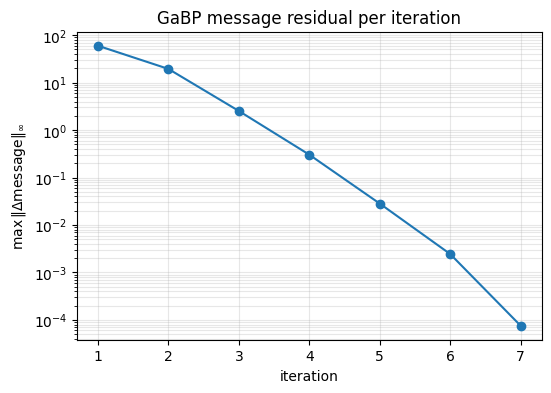

In [185]:
# GaBP implementation
def gabp(G, lambda_post, h, max_iters=20, tol=1e-4):
    N = G.N # no. of nodes
    convergence = False
    neighbours = {j : [i for i in range(N) if i != j and lambda_post[j, i] != 0] for j in range(N)}
    P_msg = np.zeros((N,N))
    m_msg = np.zeros((N,N))
    residuals = []
    for _ in range(max_iters):
        P_old = P_msg.copy() 
        m_old = m_msg.copy()
        for i in range (N):
            for j in neighbours[i]:
                P_hat = lambda_post[i, i] + sum(P_msg[k, i] for k in neighbours[i] if k != j)
                h_hat = h[i] + sum(m_msg[k, i] for k in neighbours[i] if k != j)
                P_msg[i, j] = -lambda_post[i, j]**2 / P_hat
                m_msg[i, j] = -lambda_post[i, j] * h_hat / P_hat
        
        res = max(abs(P_msg - P_old).max(), abs(m_msg - m_old).max())
        residuals.append(res)
        if res < tol:
            conv = True
            break

    mu = np.zeros(N)
    P = np.zeros(N) 
    for i in range(N):
        P[i] = lambda_post[i, i] + sum(P_msg[k, i] for k in neighbours[i])
        mu[i] = (h[i] + sum(m_msg[k, i] for k in neighbours[i])) / P[i]

    return (mu, P, conv, residuals)

(x_bay, post_var, lambda_post, h) = bayesian_gmrf(G, y)
mu, P, conv, residuals = gabp(G, lambda_post, h, 20, 1e-4)
plt.figure(figsize=(6, 4))
plt.semilogy(range(1, len(residuals) + 1), residuals, marker='o')
plt.xlabel('iteration')
plt.ylabel(r'$\max\,\|\Delta \text{message}\|_\infty$')
plt.title('GaBP message residual per iteration')
plt.grid(True, which='both', alpha=0.3)
plt.show()
